# Notebook 4 — Fault-injection digital twin

Extends the YD plant with three environmental dynamics — **temperature, pH, dissolved oxygen** —
each a first-principles ODE with an actuator/controller.




In [7]:
# ─────────────────────────────────────────────────────────────────────────
# CELL 0 — Imports and notebook configuration
# Run this once per kernel restart.
# ─────────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Reproducibility for any later noise-seeded experiments
np.random.seed(0)

# Plot defaults — match your existing notebooks
plt.rcParams.update({
    'figure.dpi'      : 110,
    'savefig.dpi'     : 110,
    'axes.grid'       : True,
    'grid.alpha'      : 0.3,
    'axes.spines.top' : False,
    'axes.spines.right': False,
})

# Sanity: which Python / which package versions
import sys, scipy
print(f"Python  {sys.version.split()[0]}")
print(f"numpy   {np.__version__}")
print(f"scipy   {scipy.__version__}")
print(f"pandas  {pd.__version__}")

Python  3.10.20
numpy   2.2.6
scipy   1.15.2
pandas  2.3.3


In [8]:
# ─────────────────────────────────────────────────────────────────────────
# CELL — YD-extended plant: model (Design B, healthy operation)
# ─────────────────────────────────────────────────────────────────────────
# Builds on YD-5. Adds a thermal ODE with proportional control and a
# re-anchored Rosso temperature modifier. This is the wrapper that the
# fault scenarios will inject into. pH and DO are held constant for now —
# their ODEs will be added when pH/DO faults are introduced.
#
# State vector (6): [X, G, E, μmax_G, μmax_E, T]
# ─────────────────────────────────────────────────────────────────────────

import numpy as np

# ── Biokinetic parameters (YD 2020, MATLAB code values) ────────────────
_KG    = 0.1     # half-saturation glucose [g/L]
_KEf   = 0.1     # half-saturation ethanol [g/L]
_Ygx   = 0.15    # yield biomass / glucose
_Yge   = 0.34    # yield ethanol / glucose
_Yex   = 0.43    # yield biomass / ethanol (ethanol respiration)

# ── Thermal envelope parameters ────────────────────────────────────────
V       = 1.35      # working volume [L]                    — YD 2020
rhoCp   = 4180.0    # heat capacity per volume [J/L/K]      — water
T_set   = 30.0      # T setpoint [°C]                       — YD 2020
T_amb   = 22.0      # ambient lab temperature [°C]          — *** CONFIRM ***
UA      = 18.0       #242*0.07 heat loss coefficient [W/K] U as the overall heat transfer coefficient A the surface — *** CONFIRM ***
K_p     = 50.0      # proportional gain [W/K]               — *** CONFIRM *** - for every 1 kelvin temp the heater works with 50 W
Q_max   = 630.0     # heater saturation [W]                 — YD - brioreactor manual
Y_QX    = 12000.0   # metabolic heat yield [J/g biomass]    — Cooney & Wang 1969

# ── Rosso cardinal T parameters (S. cerevisiae) ────────────────────────
T_min_R = 5.0       # min growth T [°C]                     — Salvadó 2011
T_opt_R = 30.0      # optimum T [°C]                        — Salvadó 2011
T_max_R = 40.0      # max growth T [°C]                     — Salvadó 2011


#T_min_R = 27.0    # Sensitive strain (generalization scenario)
#T_opt_R = 30.0
#T_max_R = 33.0

# ── Held-constant environmental inputs (will become states later) ──────
pH_const = 5.0      # YD setpoint
DO_const = 6.7      # saturation [mg/L] at 30°C — placeholder

# ── Rosso modifier, re-anchored so f_T(T_set) = 1 ──────────────────────
def f_T_raw(T):
    """Rosso (1993) cardinal T modifier, unnormalised."""
    if T <= T_min_R or T >= T_max_R:
        return 0.0
    num = (T - T_max_R) * (T - T_min_R)**2
    den = (T_opt_R - T_min_R) * (
        (T_opt_R - T_min_R) * (T - T_opt_R)
        - (T_opt_R - T_max_R) * (T_opt_R + T_min_R - 2*T)
    )
    return num / den

_fT_anchor = f_T_raw(T_set)   # normalisation; = 1 for YD (T_set == T_opt)

def f_T(T):
    """Re-anchored modifier: f_T(T_set) = 1 by construction."""
    return f_T_raw(T) / _fT_anchor

# ── Plant ODE: 6-state YD + thermal ───────────────────────────────────
def yd_plant_rhs(t, y):
    X, G, E, m1, m2, T = y
    X = max(X, 0.0); G = max(G, 0.0); E = max(E, 0.0)

    fT = f_T(T)
    muG  = m1 * G / (_KG + G) * fT if m1 > 1e-9 else 0.0
    supp = 1.0 - muG / m1          if m1 > 1e-9 else 0.0 #suppression, diauxic switch mechanism Equ. 21
    muE  = m2 * E / (_KEf + E) * supp * fT if m2 > 1e-9 else 0.0

    dX  = (muG + muE) * X
    dG  = -(muG / _Ygx) * X
    dE  = (muG * _Yge / _Ygx - muE / _Yex) * X
    dm1 = 0.0
    dm2 = 0.0

    Q_heat  = max(0.0, min(Q_max, K_p * (T_set - T)))   # W
    Q_loss  = UA * (T - T_amb)                          # W
    Q_metab = Y_QX * (muG + muE) * X * V                # J/h

    # Convert W → J/h, divide by heat capacity (J/K), result in K/h
    dT = (3600.0 * (Q_heat - Q_loss) + Q_metab) / (V * rhoCp)

    return [dX, dG, dE, dm1, dm2, dT]

print(f"YD-extended plant defined (6 states).")
print(f"  f_T(T_set={T_set}°C) = {f_T(T_set):.6f}  (should be 1.0 exactly)")
print(f"  f_T(25°C) = {f_T(25):.3f}   f_T(28°C) = {f_T(28):.3f}   f_T(35°C) = {f_T(35):.3f}")
print(f"  Thermal time constant V·ρCp/UA = {V*rhoCp/UA/60:.1f} min")

YD-extended plant defined (6 states).
  f_T(T_set=30.0°C) = 1.000000  (should be 1.0 exactly)
  f_T(25°C) = 0.873   f_T(28°C) = 0.977   f_T(35°C) = 0.800
  Thermal time constant V·ρCp/UA = 5.2 min


# Temp

Saved yd_extended_healthy.csv (601 rows)

Sanity checks:
  Mean T after 1 h:         27.890 °C   (expect ~29.7 °C, small P-offset)
  Final X:                  3.981 g/L  (expect ~4.5)
  Final G:                  -0.000 g/L  (expect ~0)
  Peak E:                   1.586 g/L at t = 1.92 h
  Glucose depletion (G<0.5): t = 1.72 h  (expect ~1.9 h)


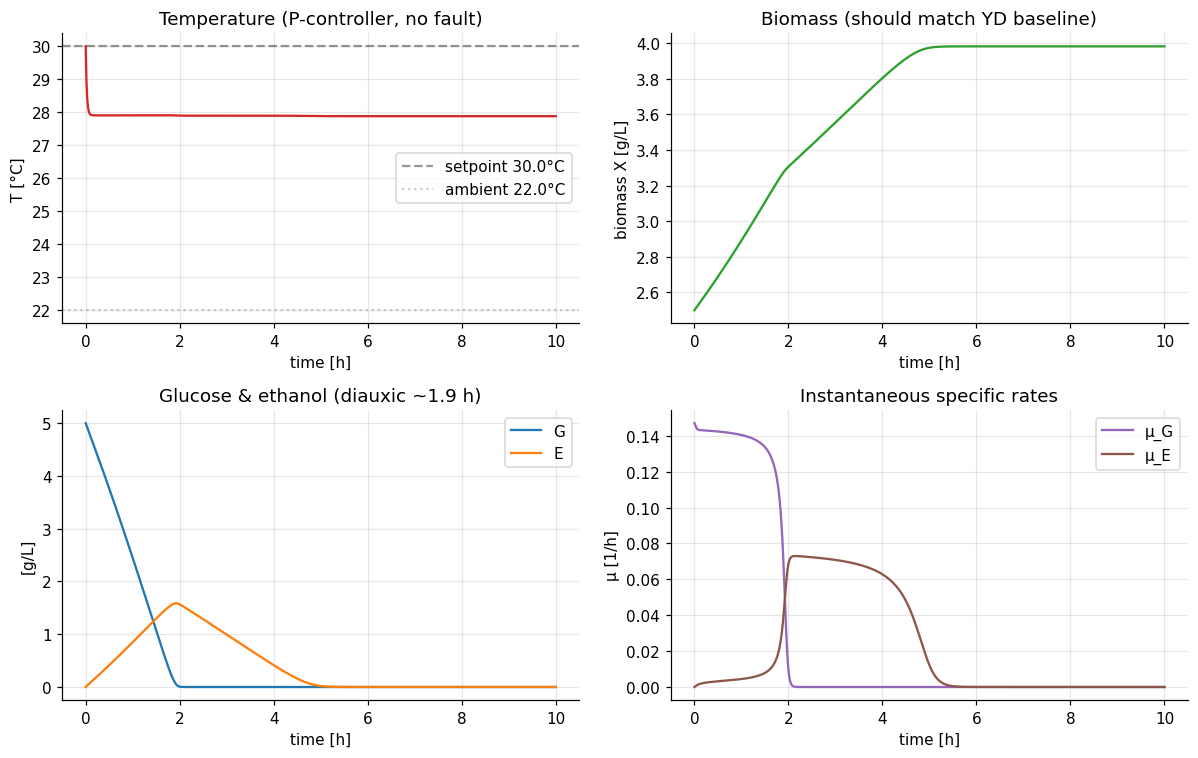

In [9]:
# ─────────────────────────────────────────────────────────────────────────
# CELL — Run YD-extended plant (healthy) → yd_extended_healthy.csv
# ─────────────────────────────────────────────────────────────────────────
# CSV columns: time_h, T, pH, DO, G, E, X, mu_G, mu_E
#   (pH and DO held constant; promoted to states when fault dynamics added)
# ─────────────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Initial conditions (YD 2020, Fig. 4 & 6)
X0     = 2.5        # biomass [g/L]
G0     = 5.0       # glucose [g/L]
E0     = 0.0        # ethanol [g/L]
mu1_0  = 0.15        # μmax_G [1/h]
mu2_0  = 0.08       # μmax_E [1/h]
T0     = T_set      # pre-warmed vessel

y0 = [X0, G0, E0, mu1_0, mu2_0, T0]

# 1-min cadence over 10 h
t_final = 10.0
t_eval  = np.linspace(0.0, t_final, int(t_final * 60) + 1)

#use interpolate
sol = solve_ivp(yd_plant_rhs, [0, t_final], y0, t_eval=t_eval,
                method='LSODA', rtol=1e-8, atol=1e-10)
assert sol.success, f"solve_ivp failed: {sol.message}"

X, G, E, m1, m2, T = sol.y
t_h = sol.t

# Recover instantaneous rates for the CSV
fT_arr = np.array([f_T(Ti) for Ti in T])
muG = np.where(m1 > 1e-9, m1 * G / (_KG + G) * fT_arr, 0.0)
supp = np.where(m1 > 1e-9, 1.0 - muG / m1, 0.0)
muE = np.where(m2 > 1e-9, m2 * E / (_KEf + E) * supp * fT_arr, 0.0)

df = pd.DataFrame({
    'time_h': t_h,
    'T'     : T,
    'pH'    : pH_const * np.ones_like(t_h),
    'DO'    : DO_const * np.ones_like(t_h),
    'G'     : G,
    'E'     : E,
    'X'     : X,
    'mu_G'  : muG,
    'mu_E'  : muE,
})
df.to_csv('data/yd_extended_healthy.csv', index=False)
print(f"Saved yd_extended_healthy.csv ({len(df)} rows)\n")

# ── Sanity checks ─────────────────────────────────────────────────────
T_late = T[60:].mean()                              # ignore first 60 min transient
idx_dep = np.argmax(G < 0.5) if (G < 0.5).any() else -1
t_dep   = t_h[idx_dep] if idx_dep > 0 else float('nan')

print(f"Sanity checks:")
print(f"  Mean T after 1 h:         {T_late:.3f} °C   (expect ~29.7 °C, small P-offset)")
print(f"  Final X:                  {X[-1]:.3f} g/L  (expect ~4.5)")
print(f"  Final G:                  {G[-1]:.3f} g/L  (expect ~0)")
print(f"  Peak E:                   {E.max():.3f} g/L at t = {t_h[np.argmax(E)]:.2f} h")
print(f"  Glucose depletion (G<0.5): t = {t_dep:.2f} h  (expect ~1.9 h)")

# ── 4-panel diagnostic ────────────────────────────────────────────────
fig, ax = plt.subplots(2, 2, figsize=(11, 7))

ax[0,0].plot(t_h, T, 'C3', lw=1.5)
ax[0,0].axhline(T_set, ls='--', color='k', alpha=0.4, label=f'setpoint {T_set}°C')
ax[0,0].axhline(T_amb, ls=':',  color='gray', alpha=0.4, label=f'ambient {T_amb}°C')
ax[0,0].set_ylabel('T [°C]'); ax[0,0].set_xlabel('time [h]')
ax[0,0].legend(); ax[0,0].grid(alpha=0.3)
ax[0,0].set_title('Temperature (P-controller, no fault)')

ax[0,1].plot(t_h, X, 'C2', lw=1.5)
ax[0,1].set_ylabel('biomass X [g/L]'); ax[0,1].set_xlabel('time [h]')
ax[0,1].grid(alpha=0.3)
ax[0,1].set_title('Biomass (should match YD baseline)')

ax[1,0].plot(t_h, G, 'C0', lw=1.5, label='G')
ax[1,0].plot(t_h, E, 'C1', lw=1.5, label='E')
ax[1,0].set_ylabel('[g/L]'); ax[1,0].set_xlabel('time [h]')
ax[1,0].legend(); ax[1,0].grid(alpha=0.3)
ax[1,0].set_title('Glucose & ethanol (diauxic ~1.9 h)')

ax[1,1].plot(t_h, muG, 'C4', lw=1.5, label='μ_G')
ax[1,1].plot(t_h, muE, 'C5', lw=1.5, label='μ_E')
ax[1,1].set_ylabel('μ [1/h]'); ax[1,1].set_xlabel('time [h]')
ax[1,1].legend(); ax[1,1].grid(alpha=0.3)
ax[1,1].set_title('Instantaneous specific rates')

plt.tight_layout()
plt.savefig('figures/yd_extended_healthy_diagnostics.png', dpi=110, bbox_inches='tight')
plt.show()

Saved yd_extended_heater_fault.csv (601 rows)

Fault signatures (faulted − healthy):
  t =  2.0 h:  ΔT = -0.00 °C   ΔE = -0.000 g/L   ΔX = -0.000 g/L
  t =  3.0 h:  ΔT = -5.85 °C   ΔE = +0.137 g/L   ΔX = -0.059 g/L
  t =  5.0 h:  ΔT = -5.84 °C   ΔE = +0.264 g/L   ΔX = -0.114 g/L
  t = 10.0 h:  ΔT = -5.88 °C   ΔE = +0.000 g/L   ΔX = -0.000 g/L


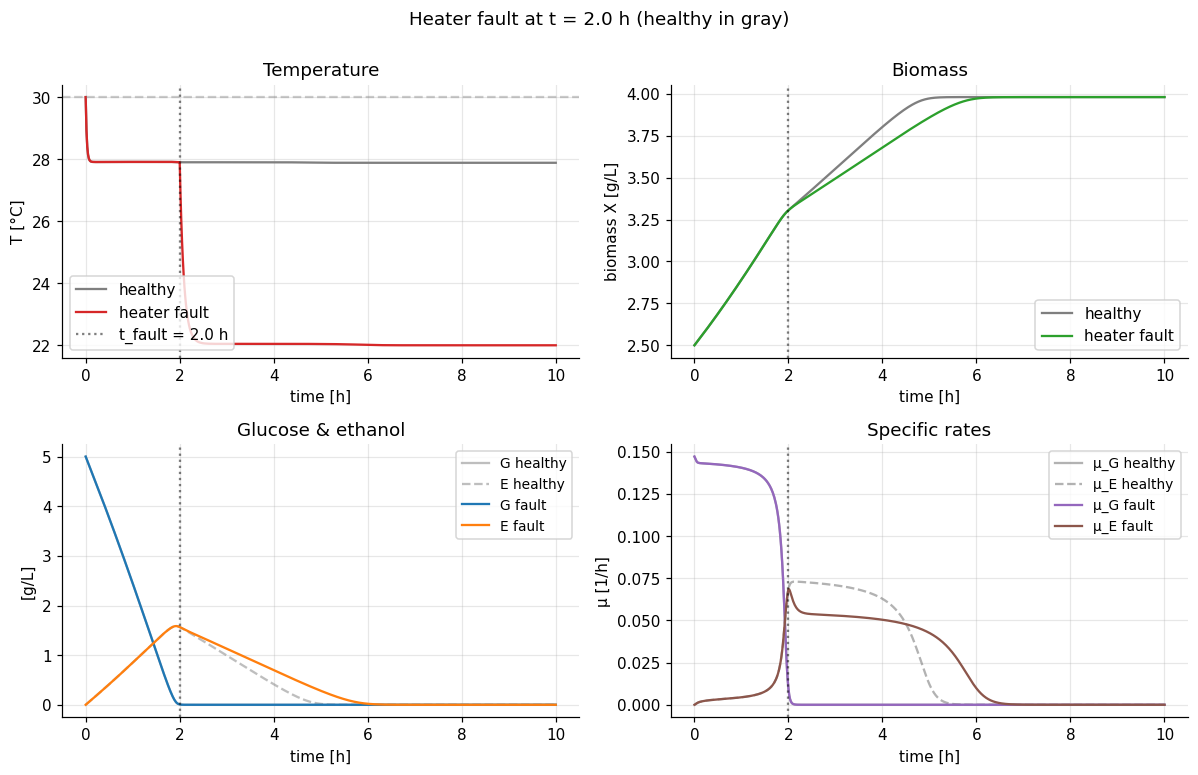

In [10]:
# ─────────────────────────────────────────────────────────────────────────
# CELL 3 — Heater fault: Q_heat → 0 at t_fault
# ─────────────────────────────────────────────────────────────────────────
# Reuses all parameters and f_T from Cell 1.
# Reads yd_extended_healthy.csv for comparison.
# Writes yd_extended_heater_fault.csv.
# ─────────────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ── Fault parameters ──────────────────────────────────────────────────
T_FAULT_H = 2.0       # heater fails at t = 2 h - peak phase is already gone no effect. 
FAULT_NAME = "heater_off"

# ── Faulted plant: heater clamps to 0 after t_fault ───────────────────
def yd_plant_rhs_fault(t, y):
    X, G, E, m1, m2, T = y
    X = max(X, 0.0); G = max(G, 0.0); E = max(E, 0.0)

    fT = f_T(T)
    muG  = m1 * G / (_KG + G) * fT if m1 > 1e-9 else 0.0
    supp = 1.0 - muG / m1          if m1 > 1e-9 else 0.0
    muE  = m2 * E / (_KEf + E) * supp * fT if m2 > 1e-9 else 0.0

    dX  = (muG + muE) * X
    dG  = -(muG / _Ygx) * X
    dE  = (muG * _Yge / _Ygx - muE / _Yex) * X
    dm1 = 0.0
    dm2 = 0.0

    # ── FAULT: heater output forced to 0 after t_fault ────────────
    if t < T_FAULT_H:
        Q_heat = max(0.0, min(Q_max, K_p * (T_set - T)))
    else:
        Q_heat = 0.0

    Q_loss  = UA * (T - T_amb)
    Q_metab = Y_QX * (muG + muE) * X * V

    dT = (3600.0 * (Q_heat - Q_loss) + Q_metab) / (V * rhoCp)

    return [dX, dG, dE, dm1, dm2, dT]

# ── Same initial conditions as healthy run ────────────────────────────
y0 = [2.5, 5.0, 0.0, 0.15, 0.08, T_set]
t_final = 10.0
t_eval  = np.linspace(0.0, t_final, int(t_final * 60) + 1)

sol = solve_ivp(yd_plant_rhs_fault, [0, t_final], y0, t_eval=t_eval,
                method='LSODA', rtol=1e-8, atol=1e-10)
assert sol.success, f"solve_ivp failed: {sol.message}"

X, G, E, m1, m2, T = sol.y
t_h = sol.t

fT_arr = np.array([f_T(Ti) for Ti in T])
muG = np.where(m1 > 1e-9, m1 * G / (_KG + G) * fT_arr, 0.0)
supp = np.where(m1 > 1e-9, 1.0 - muG / m1, 0.0)
muE = np.where(m2 > 1e-9, m2 * E / (_KEf + E) * supp * fT_arr, 0.0)

df = pd.DataFrame({
    'time_h': t_h, 'T': T,
    'pH'    : pH_const * np.ones_like(t_h),
    'DO'    : DO_const * np.ones_like(t_h),
    'G': G, 'E': E, 'X': X, 'mu_G': muG, 'mu_E': muE,
})
df.to_csv('data/yd_extended_heater_fault_tf2.0.csv', index=False)
print(f"Saved yd_extended_heater_fault.csv ({len(df)} rows)\n")

# ── Load healthy baseline for comparison ──────────────────────────────
df_h = pd.read_csv('data/yd_extended_healthy.csv')

# ── Quantitative fault signature ──────────────────────────────────────
def at_time(df, col, t):
    return float(np.interp(t, df['time_h'], df[col]))

print("Fault signatures (faulted − healthy):")
for t_eval_h in [2.0, 3.0, 5.0, 10.0]:
    dT = at_time(df,   'T', t_eval_h) - at_time(df_h, 'T', t_eval_h)
    dE = at_time(df,   'E', t_eval_h) - at_time(df_h, 'E', t_eval_h)
    dX = at_time(df,   'X', t_eval_h) - at_time(df_h, 'X', t_eval_h)
    print(f"  t = {t_eval_h:4.1f} h:  ΔT = {dT:+.2f} °C   ΔE = {dE:+.3f} g/L   ΔX = {dX:+.3f} g/L")

# ── 4-panel comparison ────────────────────────────────────────────────
fig, ax = plt.subplots(2, 2, figsize=(11, 7))

ax[0,0].plot(df_h['time_h'], df_h['T'], 'C7', lw=1.5, label='healthy')
ax[0,0].plot(t_h, T, 'C3', lw=1.5, label='heater fault')
ax[0,0].axvline(T_FAULT_H, color='k', ls=':', alpha=0.5, label=f't_fault = {T_FAULT_H} h')
ax[0,0].axhline(T_set, ls='--', color='gray', alpha=0.4)
ax[0,0].set_ylabel('T [°C]'); ax[0,0].set_xlabel('time [h]')
ax[0,0].legend(loc='lower left'); ax[0,0].grid(alpha=0.3)
ax[0,0].set_title('Temperature')

ax[0,1].plot(df_h['time_h'], df_h['X'], 'C7', lw=1.5, label='healthy')
ax[0,1].plot(t_h, X, 'C2', lw=1.5, label='heater fault')
ax[0,1].axvline(T_FAULT_H, color='k', ls=':', alpha=0.5)
ax[0,1].set_ylabel('biomass X [g/L]'); ax[0,1].set_xlabel('time [h]')
ax[0,1].legend(loc='lower right'); ax[0,1].grid(alpha=0.3)
ax[0,1].set_title('Biomass')

ax[1,0].plot(df_h['time_h'], df_h['G'], 'C7', lw=1.5, alpha=0.5, label='G healthy')
ax[1,0].plot(df_h['time_h'], df_h['E'], 'C7', lw=1.5, ls='--', alpha=0.5, label='E healthy')
ax[1,0].plot(t_h, G, 'C0', lw=1.5, label='G fault')
ax[1,0].plot(t_h, E, 'C1', lw=1.5, label='E fault')
ax[1,0].axvline(T_FAULT_H, color='k', ls=':', alpha=0.5)
ax[1,0].set_ylabel('[g/L]'); ax[1,0].set_xlabel('time [h]')
ax[1,0].legend(loc='upper right', fontsize=9); ax[1,0].grid(alpha=0.3)
ax[1,0].set_title('Glucose & ethanol')

ax[1,1].plot(df_h['time_h'], df_h['mu_G'], 'C7', lw=1.5, alpha=0.6, label='μ_G healthy')
ax[1,1].plot(df_h['time_h'], df_h['mu_E'], 'C7', lw=1.5, ls='--', alpha=0.6, label='μ_E healthy')
ax[1,1].plot(t_h, muG, 'C4', lw=1.5, label='μ_G fault')
ax[1,1].plot(t_h, muE, 'C5', lw=1.5, label='μ_E fault')
ax[1,1].axvline(T_FAULT_H, color='k', ls=':', alpha=0.5)
ax[1,1].set_ylabel('μ [1/h]'); ax[1,1].set_xlabel('time [h]')
ax[1,1].legend(loc='upper right', fontsize=9); ax[1,1].grid(alpha=0.3)
ax[1,1].set_title('Specific rates')

plt.suptitle(f'Heater fault at t = {T_FAULT_H} h (healthy in gray)', y=1.00)
plt.tight_layout()
plt.savefig(f'figures/yd_extended_{FAULT_NAME}_compare.png', dpi=110, bbox_inches='tight')
plt.show()

In [11]:
# ─────────────────────────────────────────────────────────────────────────
# CELL — Heater fault: multi-timing signature table
# ─────────────────────────────────────────────────────────────────────────
# Reads healthy + fault CSVs, computes fault effect on biomass growth.
# Produces a LaTeX booktabs-style table ready to drop into the thesis.
#
# Assumes fault CSVs are named: yd_extended_heater_fault_tf{X}.csv
# where X is the fault time in hours (0.5, 1.0, 2.0).
# ─────────────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
from scipy.integrate import trapezoid

FAULT_TIMES = [0.5, 1.0, 2.0]

df_h = pd.read_csv('data/yd_extended_healthy.csv')

# Metrics on the healthy baseline (reference values)
X_final_h = df_h['X'].iloc[-1]
intX_h    = trapezoid(df_h['X'], df_h['time_h'])
muG_peak_h = df_h['mu_G'].max()
muE_peak_h = df_h['mu_E'].max()

# Time-to-diauxic (G < 0.5) and time-to-E-depletion (E < 0.1) for context
def time_below(df, col, thresh):
    below = df[col] < thresh
    return df['time_h'][below].iloc[0] if below.any() else float('nan')

t_dep_h = time_below(df_h, 'G', 0.5)
t_Edep_h = time_below(df_h[df_h['time_h'] > t_dep_h], 'E', 0.1) if not np.isnan(t_dep_h) else float('nan')

print(f"HEALTHY BASELINE:")
print(f"  Final X:            {X_final_h:.3f} g/L")
print(f"  ∫X dt:              {intX_h:.3f} g·h/L")
print(f"  μ_G peak:           {muG_peak_h:.4f} /h")
print(f"  μ_E peak:           {muE_peak_h:.4f} /h")
print(f"  Time G < 0.5 g/L:   {t_dep_h:.2f} h")
print(f"  Time E < 0.1 g/L:   {t_Edep_h:.2f} h")
print()

# ── Collect fault results ─────────────────────────────────────────────
rows = []
for tf in FAULT_TIMES:
    fname = f'data/yd_extended_heater_fault_sensetive_tf{tf}.csv'
    try:
        df_f = pd.read_csv(fname)
    except FileNotFoundError:
        print(f"  {fname} not found — skipping.")
        continue

    X_final_f = df_f['X'].iloc[-1]
    intX_f    = trapezoid(df_f['X'], df_f['time_h'])
    muG_peak_f = df_f['mu_G'].max()
    muE_peak_f = df_f['mu_E'].max()

    t_dep_f  = time_below(df_f, 'G', 0.5)
    t_Edep_f = time_below(df_f[df_f['time_h'] > t_dep_f], 'E', 0.1) if not np.isnan(t_dep_f) else float('nan')

    # Percentages (fault relative to healthy)
    d_Xfinal   = 100 * (X_final_h - X_final_f) / X_final_h
    d_intX     = 100 * (intX_h - intX_f) / intX_h
    d_muG_peak = 100 * (muG_peak_h - muG_peak_f) / muG_peak_h
    d_muE_peak = 100 * (muE_peak_h - muE_peak_f) / muE_peak_h
    d_tdep     = t_dep_f - t_dep_h
    d_Tss      = df_f['T'].iloc[-1] - df_h['T'].iloc[-1]

    rows.append({
        't_fault [h]'      : tf,
        'ΔT_ss [°C]'       : d_Tss,
        'Δμ_G peak [%]'    : d_muG_peak,
        'Δμ_E peak [%]'    : d_muE_peak,
        'Δ∫X dt [%]'       : d_intX,
        'ΔX_final [%]'     : d_Xfinal,
        'Δt_diauxic [h]'   : d_tdep,
    })

# ── Console summary ───────────────────────────────────────────────────
tbl = pd.DataFrame(rows)
print("HEATER FAULT — effect vs healthy baseline")
print("=" * 78)
print(tbl.to_string(index=False, float_format='%+.16f'))
print()

# ── LaTeX output for the thesis ───────────────────────────────────────
print("─── LaTeX booktabs table ───")
print(r"\begin{tabular}{lrrrrr}")
print(r"\toprule")
print(r"$t_\text{fault}$ [h] & $\Delta T_\text{ss}$ [°C] & $\Delta\mu_{G,\text{peak}}$ [\%] "
      r"& $\Delta\mu_{E,\text{peak}}$ [\%] & $\Delta\int X\,dt$ [\%] & $\Delta X_\text{final}$ [\%] \\")
print(r"\midrule")
for r in rows:
    print(f"  {r['t_fault [h]']:.1f} & {r['ΔT_ss [°C]']:+.1f} & "
          f"{r['Δμ_G peak [%]']:+.1f} & {r['Δμ_E peak [%]']:+.1f} & "
          f"{r['Δ∫X dt [%]']:+.2f} & {r['ΔX_final [%]']:+.16f} \\\\")
print(r"\bottomrule")
print(r"\end{tabular}")

HEALTHY BASELINE:
  Final X:            3.981 g/L
  ∫X dt:              36.713 g·h/L
  μ_G peak:           0.1471 /h
  μ_E peak:           0.0730 /h
  Time G < 0.5 g/L:   1.72 h
  Time E < 0.1 g/L:   4.65 h

  data/yd_extended_heater_fault_sensetive_tf0.5.csv not found — skipping.
  data/yd_extended_heater_fault_sensetive_tf1.0.csv not found — skipping.
  data/yd_extended_heater_fault_sensetive_tf2.0.csv not found — skipping.
HEATER FAULT — effect vs healthy baseline
Empty DataFrame
Columns: []
Index: []

─── LaTeX booktabs table ───
\begin{tabular}{lrrrrr}
\toprule
$t_\text{fault}$ [h] & $\Delta T_\text{ss}$ [°C] & $\Delta\mu_{G,\text{peak}}$ [\%] & $\Delta\mu_{E,\text{peak}}$ [\%] & $\Delta\int X\,dt$ [\%] & $\Delta X_\text{final}$ [\%] \\
\midrule
\bottomrule
\end{tabular}


# pH

In [12]:
import warnings
# ─────────────────────────────────────────────────────────────────────────
# CELL — Extended plant with pH ODE + PI (proportional–integral) pump control
# States: [X, G, E, µmax_G, µmax_E, T, pH]
# ─────────────────────────────────────────────────────────────────────────
# The acid/base pumps are modelled as throttled PI actuators: the pump command
# is proportional to the pH error PLUS an integral of past error, saturated at
# the maximum flow. Base pump = NaOH (raises pH); acid = HCl. The command is
# sampled on a short control tick (DT_CTRL_S) and held over the tick.
#
# Fault response: a partially-stuck acid pump makes pH DIP at the fault (the
# proportional term is still small), then the integral term accumulates and
# SLOWLY drives pH back to the setpoint — a smooth dip-and-recover, not a relay
# sawtooth. Biomass keeps growing because pH is restored to the growth-
# favourable range. Only F_A_stuck > F_B_MAX runs pH away and collapses growth.
#
# (The real Minifors pumps are digital ON/OFF hardware; the PI law here is a
#  deliberate simplification chosen for a clean, readable dip-and-recover trace.)
# ─────────────────────────────────────────────────────────────────────────

import numpy as np
from scipy.integrate import solve_ivp

# ── Rosso-style cardinal pH parameters (S. cerevisiae) ────────────────
# These are the 'robust' organism profile shared with notebook 7 and
# bioreactor_ui/backend/core.py. The previous triple was (3.0, 5.0, 12.0),
# which put a pole at pH 3.833 under the n = 2 form used here — see below.
pH_set   = 5.0             # YD (2020) setpoint
pH_min_R = 2.5             # cardinal min                         ***CONFIRM***
pH_opt_R = 4.7             # cardinal opt (deliberately != setpoint)
pH_max_R = 8.0             # cardinal max                         ***CONFIRM***

# ── pH dynamics parameters ────────────────────────────────────────────
alpha_meta = 0.4           # acidogenesis [pH/h per (g/L·h⁻¹)]    ***CONFIRM***
                           # uncontrolled drop ≈ alpha_meta·ΔX ≈ 0.5 pH / batch
C_titrant  = 0.1           # M — dilute titrant                   ***assumption***
beta_buf   = 2.89e-4       # mol/L/pH — buffer capacity at pH 5 (Van Slyke, YD medium)
alpha_pump = C_titrant / 1000 / (beta_buf * V)   # ≈ 0.256 pH/mL

# ── PI controller settings ────────────────────────────────────────────
F_A_MAX   = 210.0          # acid pump max (saturation) flow [mL/h] — Infors hose
F_B_MAX   = 210.0          # base pump max (saturation) flow [mL/h]
Kc_pump   = 120.0          # PI proportional gain [mL/h per pH] — sets dip depth
Ki_pump   = 250.0          # PI integral gain [mL/h per pH·h] — sets recovery speed
DT_CTRL_S = 2.0            # control / integration tick [s]       ***CONFIRM***
# Integral time  Ti = Kc/Ki ≈ 0.48 h (~29 min); the output saturates at a pH
# error of F_B_MAX/Kc ≈ 1.75 pH (the effective proportional band).

# ── The two Rosso forms — NOT interchangeable ─────────────────────────
# n = 2 (the CTMI) is the cardinal TEMPERATURE model. Its denominator has a root
# INSIDE (v_min, v_max) whenever the optimum sits below the midpoint of the
# window, and a clip to [0, 1] hides that pole as a STEP FUNCTION. That is what
# this notebook used to do to f_pH on the triple (3.0, 5.0, 12.0): arms of 2 and
# 7, pole at pH 3.833, so f_pH returned exactly 0 below it and exactly 1 above.
# It carried no gradient at all — it could say "dead" or "fine" and nothing in
# between, which makes a pH fault either invisible or instantly lethal and
# nothing else. pH therefore uses n = 1, which has no interior pole and handles
# asymmetric arms. `_assert_monotone` below is the regression test; it FAILS on
# the old triple. (Same code as bioreactor_ui/backend/core.py and
# 7_mmae_fault_isolation.ipynb A.3.)
PHI_FLOOR = 1e-6      # never return a hard zero: that hands the EKF a zero
                      # Jacobian and the filter can never correct its way back.


def _rosso_n2(u, v_min, v_opt, v_max):
    """Rosso (1993) CTMI, n = 2 — the cardinal TEMPERATURE model."""
    if u <= v_min or u >= v_max:
        return 0.0
    num = (u - v_max) * (u - v_min) ** 2
    den = (v_opt - v_min) * ((v_opt - v_min) * (u - v_opt)
                             - (v_opt - v_max) * (v_opt + v_min - 2 * u))
    return 0.0 if abs(den) < 1e-12 else num / den


def _rosso_n1(u, v_min, v_opt, v_max):
    """Rosso n = 1 — the pH form. No interior pole, asymmetric arms handled."""
    if u <= v_min or u >= v_max:
        return 0.0
    num = (u - v_min) * (u - v_max)
    den = num - (u - v_opt) ** 2
    return 0.0 if abs(den) < 1e-12 else num / den


def _anchored(raw, v, v_min, v_opt, v_max, anchor):
    """Re-anchor so f(anchor) == 1, clipping AFTER normalisation (only below).


    Clipping to [0, 1] BEFORE dividing by f(anchor) truncates the physically
    correct f > 1 that arises when the reactor sits closer to the optimum than
    the anchor does (pH_opt 4.7 vs pH_set 5.0).
    """
    a = raw(anchor, v_min, v_opt, v_max)
    if a <= 0.0:
        raise ValueError(f"anchor {anchor} outside the viable window "
                         f"({v_min}, {v_max}): f(anchor) = {a}")
    return float(np.clip(raw(v, v_min, v_opt, v_max) / a, PHI_FLOOR, None))


def _assert_monotone(f, lo, hi, name, n=300):
    """Every modifier must rise monotonically towards its optimum.

    A Rosso denominator that changes sign inside the window is invisible in the
    output — the clip presents the pole as a clean 0/1 step — so nothing but a
    shape check catches it.
    """
    grid = np.linspace(lo, hi, n)
    curve = np.array([f(v) for v in grid])
    bad = np.where(np.diff(curve) < -1e-9)[0]
    if len(bad):
        raise ValueError(
            f"{name} is not monotone rising on [{lo}, {hi}]: {len(bad)} violations, "
            f"first at {grid[bad[0]]:.3f}. A Rosso denominator has changed sign "
            f"and the clip is hiding the pole as a step function.")
    return curve


def f_pH(pH):
    """pH modifier, Rosso n = 1, re-anchored so f_pH(pH_set) == 1."""
    return _anchored(_rosso_n1, pH, pH_min_R, pH_opt_R, pH_max_R, pH_set)


_assert_monotone(f_pH, pH_min_R + 1e-6, pH_opt_R, 'f_pH')

# ── 7-state RHS with pumps PASSED IN (held fixed over a control tick) ──
def yd_rhs_pH_fixed(t, y, F_A, F_B):
    X, G, E, m1, m2, T, pH = y
    X = max(X, 0.0); G = max(G, 0.0); E = max(E, 0.0); pH = max(pH, 1.0)

    fT_val  = f_T(T)
    fpH_val = f_pH(pH)
    muG = m1 * G / (_KG + G) * fT_val * fpH_val if m1 > 1e-9 else 0.0
    supp = 1.0 - muG / m1 if m1 > 1e-9 else 0.0
    muE = m2 * E / (_KEf + E) * supp * fT_val * fpH_val if m2 > 1e-9 else 0.0

    dX  = (muG + muE) * X
    dG  = -(muG / _Ygx) * X
    dE  = (muG * _Yge / _Ygx - muE / _Yex) * X

    Q_heat  = max(0.0, min(Q_max, K_p * (T_set - T)))
    Q_loss  = UA * (T - T_amb)
    Q_metab = Y_QX * (muG + muE) * X * V
    dT = (3600.0 * (Q_heat - Q_loss) + Q_metab) / (V * rhoCp)

    yeast_acid = alpha_meta * (muG + muE) * X
    dpH = -yeast_acid + alpha_pump * F_B - alpha_pump * F_A
    if pH <= 1.0 and dpH < 0:       # physical buffering floor
        dpH = 0.0

    return np.array([dX, dG, dE, 0.0, 0.0, dT, dpH])

# ── PI runner (shared by the healthy and fault cells) ─────────────────
def run_pH_pi(y0, t_final, fault=None, dt_ctrl_s=DT_CTRL_S):
    """Integrate the 7-state plant with PI pH control on a short tick.

    fault : None, or dict(kind=..., t_fault=<h>[, F_stuck=<mL/h>]) where kind is
            'acid_stuck' | 'base_stuck' | 'acid_off' | 'base_off'.
    Returns t [n], Y [7,n], F_A_log [n], F_B_log [n].
    """
    dt = dt_ctrl_s / 3600.0
    y = np.array(y0, dtype=float); t = 0.0
    integ = 0.0                              # pH-error integral [pH·h]
    ts, ys, FA, FB = [0.0], [y.copy()], [0.0], [0.0]
    while t < t_final - 1e-12:
        h  = min(dt, t_final - t)
        pH = y[6]
        # PI control: signed command = proportional + integral, then saturate.
        # The integral term is what slowly pushes pH back to the setpoint after
        # a fault dips it — a pure-P law would leave a steady-state offset.
        err = pH_set - pH                    # >0 → too acidic, add base
        u   = Kc_pump * err + Ki_pump * integ
        F_B = min(u, F_B_MAX) if u >= 0.0 else 0.0    # base raises pH
        F_A = min(-u, F_A_MAX) if u < 0.0 else 0.0    # acid lowers pH
        # anti-windup: freeze the integral while a pump is saturated the same way
        saturated = u > F_B_MAX or u < -F_A_MAX
        if not (saturated and (err > 0.0) == (u > 0.0)):
            integ += err * h
        # actuator faults override the controller output for t >= t_fault
        if fault is not None and t >= fault['t_fault']:
            if   fault['kind'] == 'acid_stuck': F_A = fault['F_stuck']
            elif fault['kind'] == 'base_stuck': F_B = fault['F_stuck']
            elif fault['kind'] == 'acid_off':   F_A = 0.0   # acid pump dead
            elif fault['kind'] == 'base_off':   F_B = 0.0   # base pump dead
        # RK4 step with the pumps frozen over this tick
        k1 = yd_rhs_pH_fixed(t,       y,            F_A, F_B)
        k2 = yd_rhs_pH_fixed(t + h/2, y + h/2 * k1, F_A, F_B)
        k3 = yd_rhs_pH_fixed(t + h/2, y + h/2 * k2, F_A, F_B)
        k4 = yd_rhs_pH_fixed(t + h,   y + h   * k3, F_A, F_B)
        y  = y + h/6 * (k1 + 2*k2 + 2*k3 + k4)
        y[0] = max(y[0], 0.0); y[1] = max(y[1], 0.0); y[2] = max(y[2], 0.0)
        t += h
        ts.append(t); ys.append(y.copy()); FA.append(F_A); FB.append(F_B)
    return np.array(ts), np.array(ys).T, np.array(FA), np.array(FB)

# ── Sanity check ──────────────────────────────────────────────────────
print("pH PI plant defined (7 states).")
print(f"  f_pH(pH_set={pH_set}) = {f_pH(pH_set):.6f}  (should be 1.0)")
print(f"  f_pH 4.7/4.0/3.5/3.0 = {f_pH(4.7):.3f} / {f_pH(4.0):.3f} / "
      f"{f_pH(3.5):.3f} / {f_pH(3.0):.3f}   (a CURVE, not a 0/1 step)")
print(f"  pump max flow        = base {F_B_MAX} / acid {F_A_MAX} mL/h")
print(f"  PI gains             = Kc {Kc_pump} mL/h/pH, Ki {Ki_pump} mL/h/pH·h  (Ti≈{Kc_pump/Ki_pump:.2f} h)")
print(f"  control tick         = {DT_CTRL_S} s   alpha_meta = {alpha_meta}")
_t, _Y, _, _fb = run_pH_pi([2.5, 5.0, 0.0, 0.15, 0.08, T_set, pH_set], 10.0)
print(f"  healthy pH mean(t>1h)= {_Y[6][int(3600/DT_CTRL_S):].mean():.3f}  "
      f"(min {_Y[6].min():.3f}, max {_Y[6].max():.3f})")
print(f"  healthy base ON frac = {np.mean(_fb>0):.2f}   final X = {_Y[0][-1]:.3f} g/L")



# ─────────────────────────────────────────────────────────────────────────
# IS THE SETPOINT ITSELF ANY GOOD?  (ported from bioreactor_ui/backend/plant.py)
#
# `_anchored` normalises so f(setpoint) == 1, which makes the anchored modifier
# structurally incapable of answering that question — it measures distance FROM
# the setpoint, not the quality OF it. The un-anchored value, relative to the
# organism's true optimum, is the one that does.
#
# Why it matters: a setpoint parked in a dead corner of the cardinal window
# leaves the HEALTHY reference crippled, and that inverts the whole detector — a
# fault which moves the variable back TOWARDS the optimum then makes the culture
# grow BETTER than "healthy", and no threshold reads that correctly. Observed in
# the app with pH_set = pH_max = 5.0: healthy X_end 2.50 (no growth at all),
# base-pump-off X_end 4.00, and no alarm. The anchor raise below catches the
# exactly-on-the-boundary case; this catches the near-boundary one, which is
# just as wrong and completely silent.
# ─────────────────────────────────────────────────────────────────────────
def absolute_modifier(v, v_min, v_opt, v_max, n=2):
    """The modifier at `v` relative to the organism's TRUE optimum, un-anchored."""
    raw = _rosso_n1 if n == 1 else _rosso_n2
    peak = raw(v_opt, v_min, v_opt, v_max)
    return 0.0 if peak < 1e-12 else raw(v, v_min, v_opt, v_max) / peak


def check_setpoint_quality(v_set, v_min, v_opt, v_max, n, name, floor=0.5):
    """Warn if holding at `v_set` already costs more than half the growth rate."""
    a = absolute_modifier(v_set, v_min, v_opt, v_max, n)
    if a < floor:
        warnings.warn(
            f"{name}: holding at {v_set} leaves the culture at {100*a:.0f} % of "
            f"its peak rate on cardinals ({v_min}, {v_opt}, {v_max}). The HEALTHY "
            f"reference is itself crippled, so a fault moving {name} back towards "
            f"the optimum will grow BETTER than 'healthy' and the detector reads "
            f"it backwards.", RuntimeWarning, stacklevel=2)
    return a

_ = check_setpoint_quality(pH_set, pH_min_R, pH_opt_R, pH_max_R, 1, 'pH')
print(f"  setpoint quality: pH_set sits at "
      f"{absolute_modifier(pH_set, pH_min_R, pH_opt_R, pH_max_R, 1):.3f} of the peak rate")


pH PI plant defined (7 states).
  f_pH(pH_set=5.0) = 1.000000  (should be 1.0)
  f_pH 4.7/4.0/3.5/3.0 = 1.012 / 0.936 / 0.767 / 0.469   (a CURVE, not a 0/1 step)
  pump max flow        = base 210.0 / acid 210.0 mL/h
  PI gains             = Kc 120.0 mL/h/pH, Ki 250.0 mL/h/pH·h  (Ti≈0.48 h)
  control tick         = 2.0 s   alpha_meta = 0.4
  healthy pH mean(t>1h)= 5.000  (min 4.996, max 5.002)
  healthy base ON frac = 0.54   final X = 3.981 g/L
  setpoint quality: pH_set sits at 0.988 of the peak rate


Saved yd_extended_healthy_pH.csv (18001 rows)

Healthy pH PI baseline diagnostics:
  Mean pH (t>1h):     5.000  (held near setpoint 5.0)
  pH ripple:          [4.996, 5.002]
  Base pump ON frac:  0.54   (throttled to counter acidogenesis)
  Final X:            3.981 g/L  (expect ~4.0)
  Diauxic (G<0.5):    1.71 h


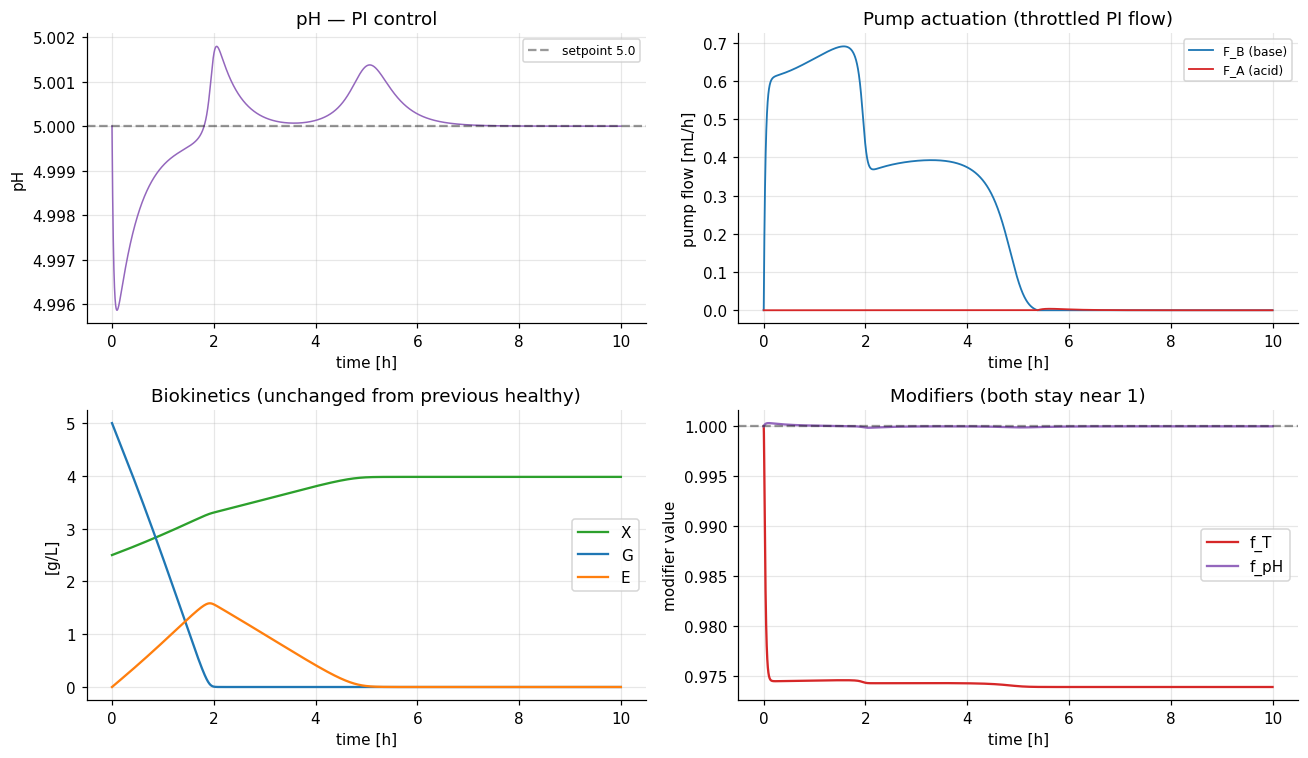

In [13]:
# ─────────────────────────────────────────────────────────────────────────
# CELL — Run healthy pH PI baseline → yd_extended_healthy_pH.csv
# ─────────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

y0 = [2.5, 5.0, 0.0, 0.15, 0.08, T_set, pH_set]
t_h, Y, FA, FB = run_pH_pi(y0, 10.0)
X, G, E, m1, m2, T, pH = Y

fT_arr  = np.array([f_T(v) for v in T])
fpH_arr = np.array([f_pH(v) for v in pH])
muG = np.where(m1 > 1e-9, m1 * G / (_KG + G) * fT_arr * fpH_arr, 0.0)
supp = np.where(m1 > 1e-9, 1.0 - muG / np.where(m1 > 1e-9, m1, 1.0), 0.0)
muE = np.where(m2 > 1e-9, m2 * E / (_KEf + E) * supp * fT_arr * fpH_arr, 0.0)

df = pd.DataFrame({'time_h': t_h, 'T': T, 'pH': pH,
                   'DO': 6.7 * np.ones_like(t_h), 'G': G, 'E': E, 'X': X,
                   'mu_G': muG, 'mu_E': muE})
df.to_csv('data/yd_extended_healthy_pH.csv', index=False)
print(f"Saved yd_extended_healthy_pH.csv ({len(df)} rows)\n")

print("Healthy pH PI baseline diagnostics:")
print(f"  Mean pH (t>1h):     {pH[int(3600/DT_CTRL_S):].mean():.3f}  (held near setpoint {pH_set})")
print(f"  pH ripple:          [{pH.min():.3f}, {pH.max():.3f}]")
print(f"  Base pump ON frac:  {np.mean(FB > 0):.2f}   (throttled to counter acidogenesis)")
print(f"  Final X:            {X[-1]:.3f} g/L  (expect ~4.0)")
print(f"  Diauxic (G<0.5):    {t_h[np.argmax(G < 0.5)]:.2f} h")

fig, ax = plt.subplots(2, 2, figsize=(12, 7))

ax[0,0].plot(t_h, pH, 'C4', lw=1.0)
ax[0,0].axhline(pH_set, ls='--', color='k', alpha=0.4, label=f'setpoint {pH_set}')
ax[0,0].set_ylabel('pH'); ax[0,0].set_xlabel('time [h]')
ax[0,0].legend(fontsize=8); ax[0,0].grid(alpha=0.3)
ax[0,0].set_title('pH — PI control')

ax[0,1].plot(t_h, FB, 'C0', lw=1.2, label='F_B (base)')
ax[0,1].plot(t_h, FA, 'C3', lw=1.2, label='F_A (acid)')
ax[0,1].set_ylabel('pump flow [mL/h]'); ax[0,1].set_xlabel('time [h]')
ax[0,1].legend(fontsize=8); ax[0,1].grid(alpha=0.3)
ax[0,1].set_title('Pump actuation (throttled PI flow)')

ax[1,0].plot(t_h, X, 'C2', lw=1.5, label='X')
ax[1,0].plot(t_h, G, 'C0', lw=1.5, label='G')
ax[1,0].plot(t_h, E, 'C1', lw=1.5, label='E')
ax[1,0].set_ylabel('[g/L]'); ax[1,0].set_xlabel('time [h]')
ax[1,0].legend(); ax[1,0].grid(alpha=0.3)
ax[1,0].set_title('Biokinetics (unchanged from previous healthy)')

ax[1,1].plot(t_h, fT_arr, 'C3', lw=1.5, label='f_T')
ax[1,1].plot(t_h, fpH_arr, 'C4', lw=1.5, label='f_pH')
ax[1,1].axhline(1.0, ls='--', color='k', alpha=0.4)
ax[1,1].set_ylabel('modifier value'); ax[1,1].set_xlabel('time [h]')
ax[1,1].legend(); ax[1,1].grid(alpha=0.3)
ax[1,1].set_title('Modifiers (both stay near 1)')

plt.tight_layout()
plt.savefig('figures/yd_extended_healthy_pH_diagnostics.png', dpi=110, bbox_inches='tight')
plt.show()


Saved acid-stuck PI CSV (18001 rows)
  F_A_stuck = 105.0 mL/h  vs  base F_B_MAX = 210.0 mL/h  →  RECOVERED (PI restores setpoint)
  pH: min 4.238, final 5.000
  base flow mean (post-fault): 105.2 mL/h
  final X 3.981 g/L  (healthy ≈ 3.98)


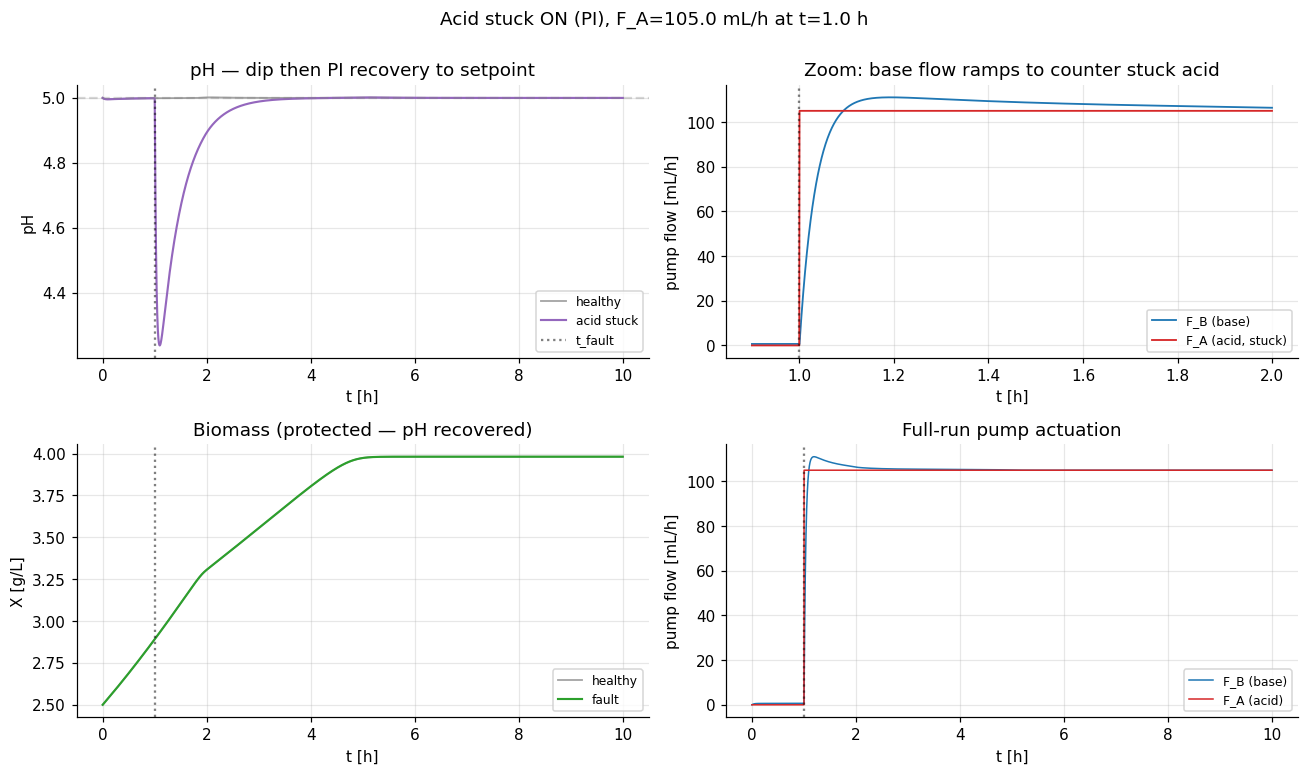

In [14]:
# ─────────────────────────────────────────────────────────────────────────
# CELL — Acid pump stuck ON (PI): pH dips, then the base pump recovers it
# ─────────────────────────────────────────────────────────────────────────
# With PI control a partially-stuck acid pump (F_A_stuck < F_B_MAX) makes pH
# DIP at the fault, then the integral term ramps the base pump up and drives
# pH back to the setpoint — a smooth dip-and-recover. Biomass keeps growing
# because pH is restored to the growth range. Only F_A_stuck > F_B_MAX runs
# pH away (try F_A_STUCK = 300 to see the crash + growth collapse below pH_min).
# ─────────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

T_FAULT_H = 1.0
F_A_STUCK = 105.0        # mL/h — partial jam (~50%); < F_B_ON = 210 → defended

y0 = [2.5, 5.0, 0.0, 0.15, 0.08, T_set, pH_set]
t_h, Y, FA, FB = run_pH_pi(
    y0, 10.0, fault=dict(kind='acid_stuck', t_fault=T_FAULT_H, F_stuck=F_A_STUCK))
X, G, E, m1, m2, T, pH = Y

fT_arr  = np.array([f_T(v) for v in T])
fpH_arr = np.array([f_pH(v) for v in pH])
muG = np.where(m1 > 1e-9, m1 * G / (_KG + G) * fT_arr * fpH_arr, 0.0)
supp = np.where(m1 > 1e-9, 1.0 - muG / np.where(m1 > 1e-9, m1, 1.0), 0.0)
muE = np.where(m2 > 1e-9, m2 * E / (_KEf + E) * supp * fT_arr * fpH_arr, 0.0)

df_f = pd.DataFrame({'time_h': t_h, 'T': T, 'pH': pH,
                     'DO': 6.7 * np.ones_like(t_h), 'G': G, 'E': E, 'X': X,
                     'mu_G': muG, 'mu_E': muE})
df_f.to_csv(f'data/yd_extended_acid_stuck_bangbang_tf{T_FAULT_H}.csv', index=False)

verdict = 'RECOVERED (PI restores setpoint)' if F_A_STUCK < F_B_MAX else 'RUNAWAY (acid > base max)'
print(f"Saved acid-stuck PI CSV ({len(df_f)} rows)")
print(f"  F_A_stuck = {F_A_STUCK} mL/h  vs  base F_B_MAX = {F_B_MAX} mL/h  →  {verdict}")
print(f"  pH: min {pH.min():.3f}, final {pH[-1]:.3f}")
print(f"  base flow mean (post-fault): {np.mean(FB[t_h>=T_FAULT_H]):.1f} mL/h")
print(f"  final X {X[-1]:.3f} g/L  (healthy ≈ 3.98)")

df_h = pd.read_csv('data/yd_extended_healthy_pH.csv')
fig, ax = plt.subplots(2, 2, figsize=(12, 7))

ax[0,0].plot(df_h['time_h'], df_h['pH'], 'C7', lw=1.2, alpha=0.7, label='healthy')
ax[0,0].plot(t_h, pH, 'C4', lw=1.4, label='acid stuck')
ax[0,0].axvline(T_FAULT_H, color='k', ls=':', alpha=0.5, label='t_fault')
ax[0,0].axhline(pH_set, ls='--', color='gray', alpha=0.3)
ax[0,0].set_ylabel('pH'); ax[0,0].set_xlabel('t [h]')
ax[0,0].legend(fontsize=8); ax[0,0].grid(alpha=0.3)
ax[0,0].set_title('pH — dip then PI recovery to setpoint')

mask = (t_h >= T_FAULT_H - 0.1) & (t_h <= T_FAULT_H + 1.0)
ax[0,1].plot(t_h[mask], FB[mask], 'C0', lw=1.2, label='F_B (base)')
ax[0,1].plot(t_h[mask], FA[mask], 'C3', lw=1.2, label='F_A (acid, stuck)')
ax[0,1].axvline(T_FAULT_H, color='k', ls=':', alpha=0.5)
ax[0,1].set_ylabel('pump flow [mL/h]'); ax[0,1].set_xlabel('t [h]')
ax[0,1].legend(fontsize=8); ax[0,1].grid(alpha=0.3)
ax[0,1].set_title('Zoom: base flow ramps to counter stuck acid')

ax[1,0].plot(df_h['time_h'], df_h['X'], 'C7', lw=1.2, alpha=0.7, label='healthy')
ax[1,0].plot(t_h, X, 'C2', lw=1.4, label='fault')
ax[1,0].axvline(T_FAULT_H, color='k', ls=':', alpha=0.5)
ax[1,0].set_ylabel('X [g/L]'); ax[1,0].set_xlabel('t [h]')
ax[1,0].legend(fontsize=8); ax[1,0].grid(alpha=0.3)
ax[1,0].set_title('Biomass (protected — pH recovered)')

ax[1,1].plot(t_h, FB, 'C0', lw=1.0, label='F_B (base)')
ax[1,1].plot(t_h, FA, 'C3', lw=1.0, label='F_A (acid)')
ax[1,1].axvline(T_FAULT_H, color='k', ls=':', alpha=0.5)
ax[1,1].set_ylabel('pump flow [mL/h]'); ax[1,1].set_xlabel('t [h]')
ax[1,1].legend(fontsize=8); ax[1,1].grid(alpha=0.3)
ax[1,1].set_title('Full-run pump actuation')

plt.suptitle(f'Acid stuck ON (PI), F_A={F_A_STUCK} mL/h at t={T_FAULT_H} h', y=1.00)
plt.tight_layout()
plt.savefig(f'figures/yd_acid_stuck_bangbang_tf{T_FAULT_H}.png', dpi=110, bbox_inches='tight')
plt.show()


In [15]:
# ─────────────────────────────────────────────────────────────────────────
# DIAGNOSTIC — per-window trace of pH and pump activity (PI)
# Run AFTER the acid-pump-stuck cell: uses its t_h, X, pH, muG, muE and the
# logged FA / FB pump actuation arrays. The PI pump flow is continuous; we
# show the AVERAGE flow per 30-min window — the base pump's rising average
# is the fault signature.
# ─────────────────────────────────────────────────────────────────────────

print(f"{'t[h]':>9} {'pH':>7} {'<F_A>':>8} {'<F_B>':>8} {'yeast':>8} {'net_dpH':>9}  status")
print("-" * 80)

edges = np.arange(0.0, 10.01, 0.5)
for a, b in zip(edges[:-1], edges[1:]):
    m = (t_h >= a) & (t_h < b)
    if not m.any():
        continue
    pH_w  = pH[m].mean()
    FA_w  = FA[m].mean()          # average acid flow [mL/h]
    FB_w  = FB[m].mean()          # average base flow [mL/h]
    yeast = (alpha_meta * (muG[m] + muE[m]) * X[m]).mean()
    net   = -yeast + alpha_pump * FB_w - alpha_pump * FA_w
    status = "ACID STUCK" if a >= T_FAULT_H else "healthy"
    if FB_w > 0.9 * F_B_MAX:
        note = "base near max - losing"
    elif abs(net) < 0.02:
        note = "= balanced (defended)"
    elif net < 0:
        note = "pH falling"
    else:
        note = "pH rising"
    print(f"{a:>4.1f}-{b:<4.1f} {pH_w:>7.3f} {FA_w:>8.1f} {FB_w:>8.1f} "
          f"{yeast:>8.3f} {net:>+9.3f}  {status}: {note}")


     t[h]      pH    <F_A>    <F_B>    yeast   net_dpH  status
--------------------------------------------------------------------------------
 0.0-0.5    4.997      0.0      0.6    0.151    -0.004  healthy: = balanced (defended)
 0.5-1.0    4.999      0.0      0.6    0.162    +0.002  healthy: = balanced (defended)
 1.0-1.5    4.455    104.9    103.0    0.172    -0.667  ACID STUCK: pH falling
 1.5-2.0    4.800    105.0    107.4    0.160    +0.455  ACID STUCK: pH rising
 2.0-2.5    4.936    105.0    105.9    0.099    +0.144  ACID STUCK: pH rising
 2.5-3.0    4.979    105.0    105.6    0.100    +0.047  ACID STUCK: pH rising
 3.0-3.5    4.993    105.0    105.5    0.101    +0.015  ACID STUCK: = balanced (defended)
 3.5-4.0    4.998    105.0    105.4    0.099    +0.005  ACID STUCK: = balanced (defended)
 4.0-4.5    5.000    105.0    105.4    0.087    +0.002  ACID STUCK: = balanced (defended)
 4.5-5.0    5.001    105.0    105.2    0.048    +0.002  ACID STUCK: = balanced (defended)
 5.0-5.5 

Saved yd_extended_base_off_tf0.5.csv (18001 rows)
  pH: start 5.0, final 4.481 (drift +0.519), min 4.481
  base pump ON after fault: 0.00  (0 = dead)
  final X 3.981 g/L  (healthy ≈ 3.98)


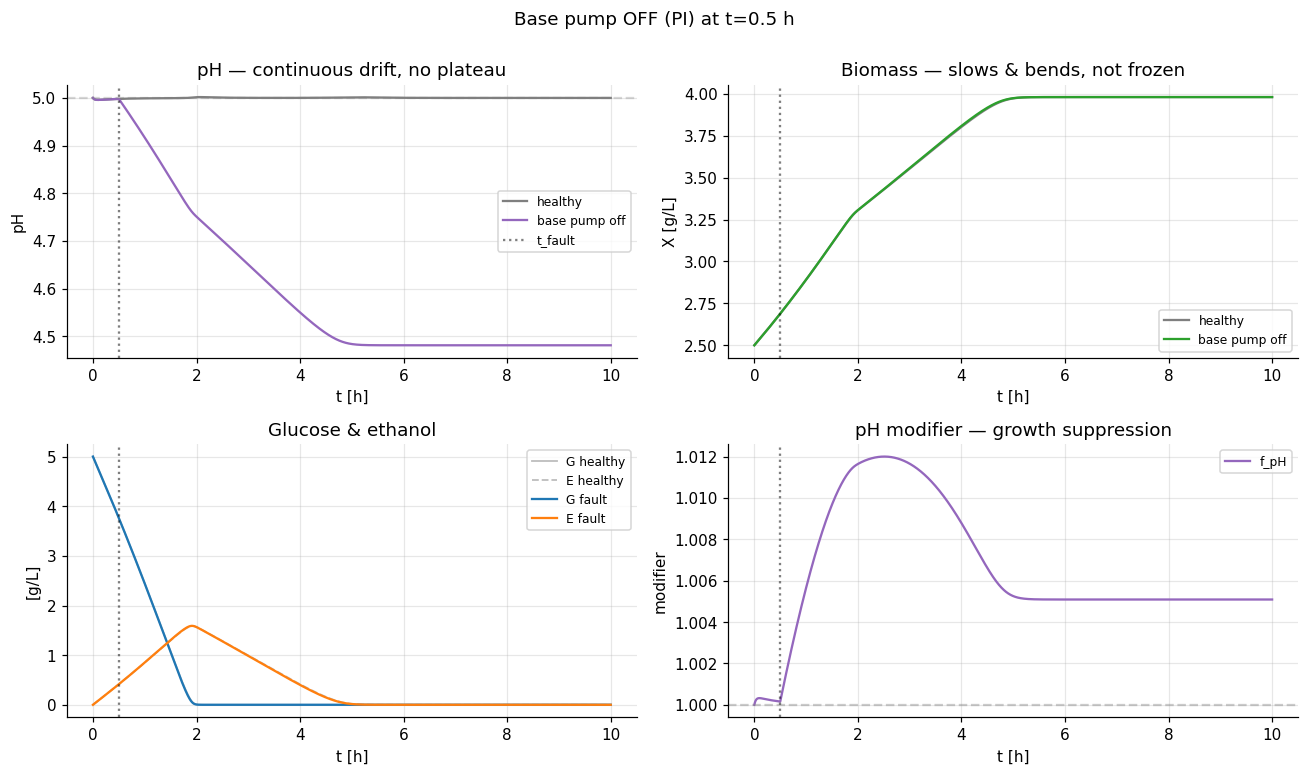

In [16]:
# ─────────────────────────────────────────────────────────────────────────
# CELL — Base pump OFF fault (PI): pH drifts down, growth-coupled
# ─────────────────────────────────────────────────────────────────────────
# Mechanism: the base pump dies at t_fault (F_B forced to 0). The acid pump
# is idle anyway (pH sits below the setpoint), so yeast acidogenesis is now
# UNCOMPENSATED — pH drifts DOWN, fastest during peak growth and leveling as
# growth slows. A continuous decline, no plateau. Unlike the acid-stuck
# fault (an active pump drives pH hard), the drift here is only as strong as
# the cells' own acid production: total drop ≈ alpha_meta · (biomass formed).
# It suppresses growth via f_pH only once pH falls far enough; the biomass
# curve therefore bends gently rather than freezing.
# ─────────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

T_FAULT_BASE_H = 0.5      # base pump dies at t = 0.5 h

y0 = [2.5, 5.0, 0.0, 0.15, 0.08, T_set, pH_set]
t_h, Y, FA, FB = run_pH_pi(
    y0, 10.0, fault=dict(kind='base_off', t_fault=T_FAULT_BASE_H))
X, G, E, m1, m2, T, pH = Y

fT_a  = np.array([f_T(v) for v in T])
fpH_a = np.array([f_pH(v) for v in pH])
muG = np.where(m1 > 1e-9, m1 * G / (_KG + G) * fT_a * fpH_a, 0.0)
supp = np.where(m1 > 1e-9, 1.0 - muG / np.where(m1 > 1e-9, m1, 1.0), 0.0)
muE = np.where(m2 > 1e-9, m2 * E / (_KEf + E) * supp * fT_a * fpH_a, 0.0)

df_f = pd.DataFrame({'time_h': t_h, 'T': T, 'pH': pH, 'DO': 6.7 * np.ones_like(t_h),
    'G': G, 'E': E, 'X': X, 'mu_G': muG, 'mu_E': muE})
df_f.to_csv(f'data/yd_extended_base_off_tf{T_FAULT_BASE_H}.csv', index=False)
print(f"Saved yd_extended_base_off_tf{T_FAULT_BASE_H}.csv ({len(df_f)} rows)")
print(f"  pH: start {pH_set}, final {pH[-1]:.3f} (drift {pH_set - pH[-1]:+.3f}), min {pH.min():.3f}")
print(f"  base pump ON after fault: {np.mean(FB[t_h >= T_FAULT_BASE_H] > 0):.2f}  (0 = dead)")
print(f"  final X {X[-1]:.3f} g/L  (healthy ≈ 3.98)")

df_h = pd.read_csv('data/yd_extended_healthy_pH.csv')
fig, ax = plt.subplots(2, 2, figsize=(12, 7))

ax[0,0].plot(df_h['time_h'], df_h['pH'], 'C7', lw=1.5, label='healthy')
ax[0,0].plot(t_h, pH, 'C4', lw=1.5, label='base pump off')
ax[0,0].axvline(T_FAULT_BASE_H, color='k', ls=':', alpha=0.5, label='t_fault')
ax[0,0].axhline(pH_set, ls='--', color='gray', alpha=0.3)
ax[0,0].set_ylabel('pH'); ax[0,0].set_xlabel('t [h]')
ax[0,0].legend(fontsize=8); ax[0,0].grid(alpha=0.3)
ax[0,0].set_title('pH — continuous drift, no plateau')

ax[0,1].plot(df_h['time_h'], df_h['X'], 'C7', lw=1.5, label='healthy')
ax[0,1].plot(t_h, X, 'C2', lw=1.5, label='base pump off')
ax[0,1].axvline(T_FAULT_BASE_H, color='k', ls=':', alpha=0.5)
ax[0,1].set_ylabel('X [g/L]'); ax[0,1].set_xlabel('t [h]')
ax[0,1].legend(fontsize=8); ax[0,1].grid(alpha=0.3)
ax[0,1].set_title('Biomass — slows & bends, not frozen')

ax[1,0].plot(df_h['time_h'], df_h['G'], 'C7', lw=1.2, alpha=0.5, label='G healthy')
ax[1,0].plot(df_h['time_h'], df_h['E'], 'C7', lw=1.2, ls='--', alpha=0.5, label='E healthy')
ax[1,0].plot(t_h, G, 'C0', lw=1.5, label='G fault')
ax[1,0].plot(t_h, E, 'C1', lw=1.5, label='E fault')
ax[1,0].axvline(T_FAULT_BASE_H, color='k', ls=':', alpha=0.5)
ax[1,0].set_ylabel('[g/L]'); ax[1,0].set_xlabel('t [h]')
ax[1,0].legend(fontsize=8); ax[1,0].grid(alpha=0.3)
ax[1,0].set_title('Glucose & ethanol')

ax[1,1].plot(t_h, fpH_a, 'C4', lw=1.5, label='f_pH')
ax[1,1].axhline(1.0, ls='--', color='gray', alpha=0.4)
ax[1,1].axvline(T_FAULT_BASE_H, color='k', ls=':', alpha=0.5)
ax[1,1].set_ylabel('modifier'); ax[1,1].set_xlabel('t [h]')
ax[1,1].legend(fontsize=8); ax[1,1].grid(alpha=0.3)
ax[1,1].set_title('pH modifier — growth suppression')

plt.suptitle(f'Base pump OFF (PI) at t={T_FAULT_BASE_H} h', y=1.00)
plt.tight_layout()
plt.savefig(f'figures/yd_base_off_bangbang_tf{T_FAULT_BASE_H}.png', dpi=110, bbox_inches='tight')
plt.show()


# DO

In [17]:
# ─────────────────────────────────────────────────────────────────────────
# CELL — DO (dissolved oxygen) parameters
# Free-floating mass balance (YD held aeration/agitation constant, no DO control).
# DO expressed in % saturation, matching the Minifors pO2 probe (0-150% range).
# ─────────────────────────────────────────────────────────────────────────

import numpy as np

# ── Operating conditions (YD paper, Minifors 2) ───────────────────────
N_rpm      = 500.0    # agitation [rpm]          — YD 2020  ← agitation-fault target
Q_air_Lmin = 3.5      # aeration [L/min]         — YD 2020  ← aeration-fault target

# ── Vessel geometry (for kLa correlation) ─────────────────────────────
D_vessel_m = 0.090    # vessel inner diameter [m], DN 90    ***CONFIRM from manual***
D_imp_frac = 1/3      # impeller/vessel diameter ratio (Rushton)
N_power    = 5.0      # power number per 6-blade Rushton turbine, turbulent
N_impellers = 2       # two 6-blade Rushton turbines on the shaft (Minifors manual)
rho_broth  = 1000.0   # broth density [kg/m³] ~ water
Pg_P0      = 0.5      # gassed/ungassed power ratio          ***CONFIRM***

# ── Van't Riet correlation constants (non-coalescing broth) ───────────
VR_C, VR_a, VR_b = 0.002, 0.7, 0.2   # kLa = C·(Pg/V)^a · vs^b   [1/s]

def compute_kLa(N_rpm=N_rpm, Q_air_Lmin=Q_air_Lmin,
                V_L=V, D_vessel_m=D_vessel_m):
    """kLa [1/h] from agitation + aeration (Van't Riet). Change args per reactor."""
    V_m3    = V_L / 1000.0
    A_cross = np.pi/4 * D_vessel_m**2
    D_imp   = D_vessel_m * D_imp_frac
    N_rps   = N_rpm / 60.0
    v_s     = (Q_air_Lmin/1000.0/60.0) / A_cross          # superficial gas vel [m/s]
    P0      = N_impellers * N_power * rho_broth * N_rps**3 * D_imp**5   # 2 Rushtons: additive power [W]
    Pg_V    = (Pg_P0 * P0) / V_m3                           # gassed power/vol [W/m³]
    return VR_C * (Pg_V**VR_a) * (v_s**VR_b) * 3600.0       # [1/h]

# ── DO mass-balance parameters ────────────────────────────────────────
kLa_0    = compute_kLa()      # healthy kLa [1/h] — computed from N & Q_air
DO_star  = 100.0              # saturation [% sat] — probe reference, 100% by def.
qO2_max  = 8.0               # specific O2 uptake [mg O2 /(g·h)]  Sonnleitner&Käppeli 1986 ***CONFIRM***
DO_sat_mgL = 6.7             # saturation in mg/L (to convert qO2 into %-sat units)
K_O_pct  = 3.0               # Monod half-sat for O2 [% sat] (≈0.2 mg/L / 6.7)  Furukawa 1983
DO0      = 100.0             # initial DO [% sat] — starts saturated at inoculation

# ── DO growth modifier (RE-ANCHORED Monod saturation, NOT bell-curve) ─
# Re-anchored so f_DO(DO_star) = 1: at saturation there is NO growth penalty,
# only the deficit below saturation damps growth (mirrors the f_T / f_pH
# cardinal anchoring). Without this the raw Monod gives f_DO(100)=100/103≈0.971,
# damping the healthy baseline ~3%.
_fDO_anchor = DO_star / (K_O_pct + DO_star)
def f_DO(DO_pct):
    """Oxygen limitation factor in [0,1], f_DO(DO_star)=1. Drops as DO->0."""
    DO_pct = max(DO_pct, 0.0)
    return max(0.0, min(1.0, (DO_pct / (K_O_pct + DO_pct)) / _fDO_anchor))

# ── Sanity print ──────────────────────────────────────────────────────
print(f"kLa (healthy, {N_rpm:.0f} rpm, {Q_air_Lmin} L/min) = {kLa_0:.1f} 1/h")
print(f"  agitator half-speed (250 rpm): kLa = {compute_kLa(N_rpm=250):.1f} 1/h")
print(f"  air filter clog (1.0 L/min):   kLa = {compute_kLa(Q_air_Lmin=1.0):.1f} 1/h")
print(f"f_DO(100%) = {f_DO(100):.3f}   f_DO(10%) = {f_DO(10):.3f}   f_DO(3%) = {f_DO(3):.3f}")
print(f"DO0 = {DO0}% sat, DO* = {DO_star}% sat, K_O = {K_O_pct}% sat")


kLa (healthy, 500 rpm, 3.5 L/min) = 44.8 1/h
  agitator half-speed (250 rpm): kLa = 10.5 1/h
  air filter clog (1.0 L/min):   kLa = 34.9 1/h
f_DO(100%) = 1.000   f_DO(10%) = 0.792   f_DO(3%) = 0.515
DO0 = 100.0% sat, DO* = 100.0% sat, K_O = 3.0% sat


In [18]:
# ─────────────────────────────────────────────────────────────────────────
# CELL — 8-state plant with DO + PI pH control.  φ = f_T · f_pH · f_DO
# States: [X, G, E, µmax_G, µmax_E, T, pH, DO]
# DO free-floating (no controller): supply kLa·(DO*−DO) vs respiratory demand.
# Pumps AND kLa are passed in (held over a control tick) so the SAME runner
# reproduces the PI pH controller (cell 9) and injects agitation/aeration
# faults by lowering kLa. This mirrors the app backend (plant.py + simulator.py).
# ─────────────────────────────────────────────────────────────────────────

def yd_rhs_DO_fixed(t, y, F_A, F_B, kLa):
    """8-state RHS with pumps + kLa held fixed over a control tick."""
    X, G, E, m1, m2, T, pH, DO = y
    X = max(X, 0.0); G = max(G, 0.0); E = max(E, 0.0)
    pH = max(pH, 1.0); DO = max(DO, 0.0)

    # Single shared environmental modifier: f_DO folds into φ like f_T / f_pH.
    phi = f_T(T) * f_pH(pH) * f_DO(DO)
    muG = m1 * G / (_KG + G) * phi if m1 > 1e-9 else 0.0
    supp = 1.0 - muG / m1 if m1 > 1e-9 else 0.0
    muE = m2 * E / (_KEf + E) * supp * phi if m2 > 1e-9 else 0.0

    dX  = (muG + muE) * X
    dG  = -(muG / _Ygx) * X
    dE  = (muG * _Yge / _Ygx - muE / _Yex) * X

    Q_heat  = max(0.0, min(Q_max, K_p * (T_set - T)))
    Q_loss  = UA * (T - T_amb)
    Q_metab = Y_QX * (muG + muE) * X * V
    dT = (3600.0 * (Q_heat - Q_loss) + Q_metab) / (V * rhoCp)

    yeast_acid = alpha_meta * (muG + muE) * X
    dpH = -yeast_acid + alpha_pump * F_B - alpha_pump * F_A
    if pH <= 1.0 and dpH < 0:
        dpH = 0.0

    # DO ODE (%-sat/h): OTR supply − respiratory OUR demand.
    #   OUR is a specific-uptake heuristic scaled by growth activity;
    #   demand [mg/(L·h)] → %-sat/h via /DO_sat_mgL·100.
    supply = kLa * (DO_star - DO)
    demand = (qO2_max * (muG + muE) / (m1 + m2 + 1e-9)) * X
    dDO = supply - demand / DO_sat_mgL * 100.0
    if DO <= 0.0 and dDO < 0:       # physical floor: DO can't go negative
        dDO = 0.0

    return np.array([dX, dG, dE, 0.0, 0.0, dT, dpH, dDO])


def run_DO_pi(y0, t_final, fault=None, aer=None, dt_ctrl_s=DT_CTRL_S):
    """8-state plant with PI pH control (cell 9) + free-floating DO.

    fault : pH-pump fault dict(kind=..., t_fault=<h>[, F_stuck=..]) or None.
    aer   : aeration/agitation fault dict(t_fault=<h>[, N_rpm=.., Q_air_Lmin=..])
            recomputing a reduced kLa for t >= t_fault, or None.
    Returns t [n], Y [8,n], F_A_log [n], F_B_log [n], kLa_log [n].
    """
    dt = dt_ctrl_s / 3600.0
    y = np.array(y0, dtype=float); t = 0.0
    integ = 0.0                                  # pH-error integral [pH·h]
    kLa_fault = (compute_kLa(N_rpm=aer.get('N_rpm', N_rpm),
                             Q_air_Lmin=aer.get('Q_air_Lmin', Q_air_Lmin))
                 if aer is not None else None)
    ts, ys, FA, FB, KL = [0.0], [y.copy()], [0.0], [0.0], [kLa_0]
    while t < t_final - 1e-12:
        h  = min(dt, t_final - t)
        pH = y[6]
        # PI pH control (identical law to run_pH_pi)
        err = pH_set - pH
        u   = Kc_pump * err + Ki_pump * integ
        F_B = min(u, F_B_MAX) if u >= 0.0 else 0.0
        F_A = min(-u, F_A_MAX) if u < 0.0 else 0.0
        saturated = u > F_B_MAX or u < -F_A_MAX
        if not (saturated and (err > 0.0) == (u > 0.0)):
            integ += err * h
        # pH-pump actuator faults override the controller for t >= t_fault
        if fault is not None and t >= fault['t_fault']:
            if   fault['kind'] == 'acid_stuck': F_A = fault['F_stuck']
            elif fault['kind'] == 'base_stuck': F_B = fault['F_stuck']
            elif fault['kind'] == 'acid_off':   F_A = 0.0
            elif fault['kind'] == 'base_off':   F_B = 0.0
        # aeration/agitation fault: reduced kLa for t >= t_fault
        kLa = kLa_fault if (aer is not None and t >= aer['t_fault']) else kLa_0
        # RK4 step with pumps + kLa frozen over this tick
        k1 = yd_rhs_DO_fixed(t,       y,            F_A, F_B, kLa)
        k2 = yd_rhs_DO_fixed(t + h/2, y + h/2 * k1, F_A, F_B, kLa)
        k3 = yd_rhs_DO_fixed(t + h/2, y + h/2 * k2, F_A, F_B, kLa)
        k4 = yd_rhs_DO_fixed(t + h,   y + h   * k3, F_A, F_B, kLa)
        y  = y + h/6 * (k1 + 2*k2 + 2*k3 + k4)
        y[0]=max(y[0],0.0); y[1]=max(y[1],0.0); y[2]=max(y[2],0.0); y[7]=max(y[7],0.0)
        t += h
        ts.append(t); ys.append(y.copy()); FA.append(F_A); FB.append(F_B); KL.append(kLa)
    return np.array(ts), np.array(ys).T, np.array(FA), np.array(FB), np.array(KL)

# ── Sanity check ──────────────────────────────────────────────────────
y0_DO = [2.5, 5.0, 0.0, 0.15, 0.08, T_set, pH_set, DO0]
_t, _Y, _, _, _ = run_DO_pi(y0_DO, 10.0)
print("8-state plant with DO + PI pH control defined.")
print(f"  φ = f_T · f_pH · f_DO   (single shared modifier)")
print(f"  f_DO(DO_star={DO_star}) = {f_DO(DO_star):.4f}  (should be 1.0)")
print(f"  healthy: final X = {_Y[0][-1]:.3f} g/L,  DO min = {_Y[7].min():.1f}% "
      f"(t={_t[_Y[7].argmin()]:.2f} h)")


8-state plant with DO + PI pH control defined.
  φ = f_T · f_pH · f_DO   (single shared modifier)
  f_DO(DO_star=100.0) = 1.0000  (should be 1.0)
  healthy: final X = 3.981 g/L,  DO min = 94.9% (t=1.58 h)


kLa: healthy 44.8 → aeration fault 10.5 1/h
DO min: healthy 94.9%  vs  aeration-fault 78.3%
final X: healthy 3.981  vs  fault 3.981 g/L
wrote yd_extended_aeration_fault.csv  (DO column = state, % sat)


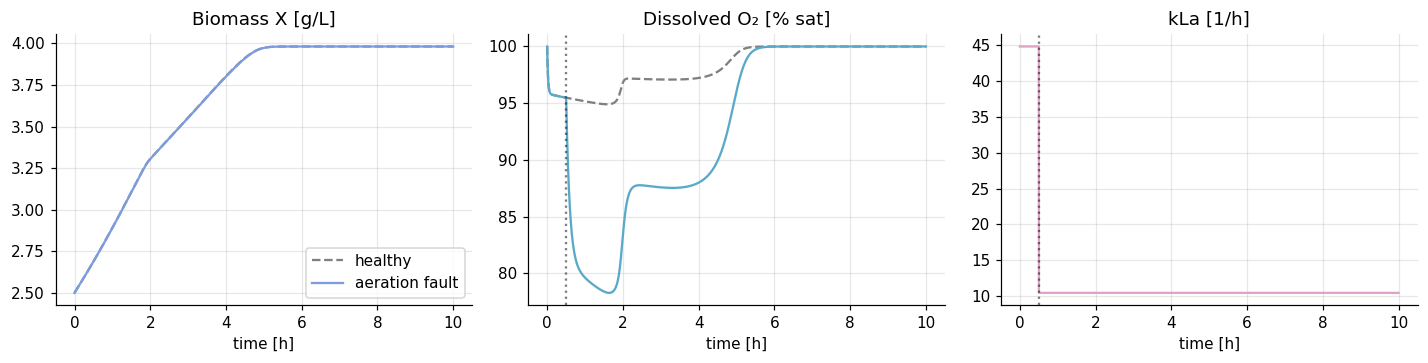

In [19]:
# ─────────────────────────────────────────────────────────────────────────
# CELL — Aeration/agitation fault demo + DO-from-state CSV export
# Halve agitation (500→250 rpm) at t_fault: kLa drops, DO dips during active
# respiration, growth barely eased (f_DO≈1 until DO nears K_O). The DO probe
# clearly shows the fault → a DO-observable fault (the EKF, blind to it via φ).
# ─────────────────────────────────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt

t_fault = 0.5
th, Yh, _,  _,  _   = run_DO_pi(y0_DO, 10.0)                                    # healthy
ta, Ya, _,  _,  KLa = run_DO_pi(y0_DO, 10.0, aer={'t_fault': t_fault, 'N_rpm': 250.0})

print(f"kLa: healthy {kLa_0:.1f} → aeration fault {KLa[-1]:.1f} 1/h")
print(f"DO min: healthy {Yh[7].min():.1f}%  vs  aeration-fault {Ya[7].min():.1f}%")
print(f"final X: healthy {Yh[0][-1]:.3f}  vs  fault {Ya[0][-1]:.3f} g/L")

# DO written from the STATE (% sat), not the 6.7 mg/L constant used elsewhere.
df = pd.DataFrame({
    'time_h': ta, 'X': Ya[0], 'G': Ya[1], 'E': Ya[2],
    'T': Ya[5], 'pH': Ya[6], 'DO': Ya[7],
})
df.to_csv('data/yd_extended_aeration_fault.csv', index=False)
print("wrote yd_extended_aeration_fault.csv  (DO column = state, % sat)")

fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
ax[0].plot(th, Yh[0], '--', c='gray', label='healthy')
ax[0].plot(ta, Ya[0], c='#7c9ce0', label='aeration fault')
ax[0].set_title('Biomass X [g/L]'); ax[0].legend()
ax[1].plot(th, Yh[7], '--', c='gray'); ax[1].plot(ta, Ya[7], c='#5aa9c9')
ax[1].axvline(t_fault, c='k', ls=':', alpha=.5); ax[1].set_title('Dissolved O₂ [% sat]')
ax[2].plot(ta, KLa, c='#e0a3c8'); ax[2].axvline(t_fault, c='k', ls=':', alpha=.5)
ax[2].set_title('kLa [1/h]')
for a in ax:
    a.set_xlabel('time [h]'); a.grid(alpha=.3)
fig.tight_layout(); plt.show()
